In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r"D:\Projects\Fda\data\Processed Data\food_delivery_cleaned.csv")
df.head()

,Age,Rating,Weather_conditions,Traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance,Preparation_Time,Delivery_Time
0,36.0,4.2,Fog,3,2,Snack,motorcycle,3.0,0,Metropolitian,46,10.280582,15.0,31.0
1,21.0,4.7,Stormy,2,1,Meal,motorcycle,1.0,0,Metropolitian,23,6.242319,10.0,13.0
2,23.0,4.7,Sandstorms,1,1,Drinks,scooter,1.0,0,Metropolitian,21,13.787860,10.0,11.0
3,34.0,4.3,Sandstorms,0,0,Buffet,motorcycle,0.0,0,Metropolitian,20,2.930258,10.0,10.0
4,24.0,4.7,Fog,3,1,Snack,scooter,1.0,0,Metropolitian,41,19.396618,15.0,26.0


Defining Late Delivery

In [4]:
df['late_delivery_time'] = df['Time_taken (min)'] > 30
print(df['late_delivery_time'].value_counts())

late_delivery_time
False    30773
True     13080
Name: count, dtype: int64


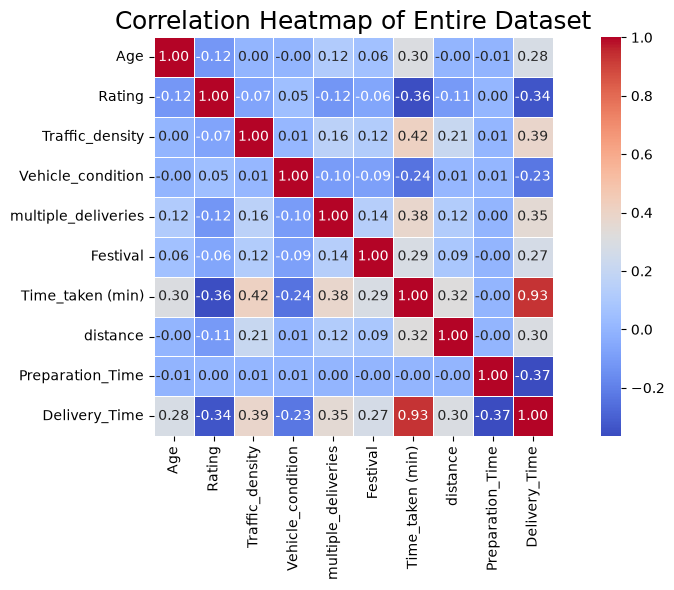

In [5]:
numeric_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar=True
)

plt.title("Correlation Heatmap of Entire Dataset", fontsize=18)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()

plt.show()

Univariate: Late Rate by Category

In [7]:
cat_features = ['Weather_conditions', 'Traffic_density', 'Vehicle_condition',
                'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries',
                'Festival', 'City']

for feature in cat_features:
    analysis = (
        df.groupby(feature)
          .agg(Total_Deliveries=('late_delivery_time', 'count'),
               Late_Deliveries=('late_delivery_time', 'sum'))
    )
    analysis['Late_Rate (%)'] = (analysis['Late_Deliveries'] / analysis['Total_Deliveries'] * 100).round(2)
    analysis = analysis.sort_values('Late_Rate (%)', ascending=False)
    print(f"\n{'='*60}\nLate Delivery Rate by: {feature}\n{'='*60}")
    print(analysis)


Late Delivery Rate by: Weather_conditions
                    Total_Deliveries  Late_Deliveries  Late_Rate (%)
Weather_conditions                                                  
Cloudy                          7336             3217          43.85
Fog                             7475             3276          43.83
Windy                           7251             1928          26.59
Sandstorms                      7284             1891          25.96
Stormy                          7400             1887          25.50
Sunny                           7107              881          12.40

Late Delivery Rate by: Traffic_density
                 Total_Deliveries  Late_Deliveries  Late_Rate (%)
Traffic_density                                                  
3                           13796             6977          50.57
2                            4320             1442          33.38
1                           10676             3475          32.55
0                           15061  

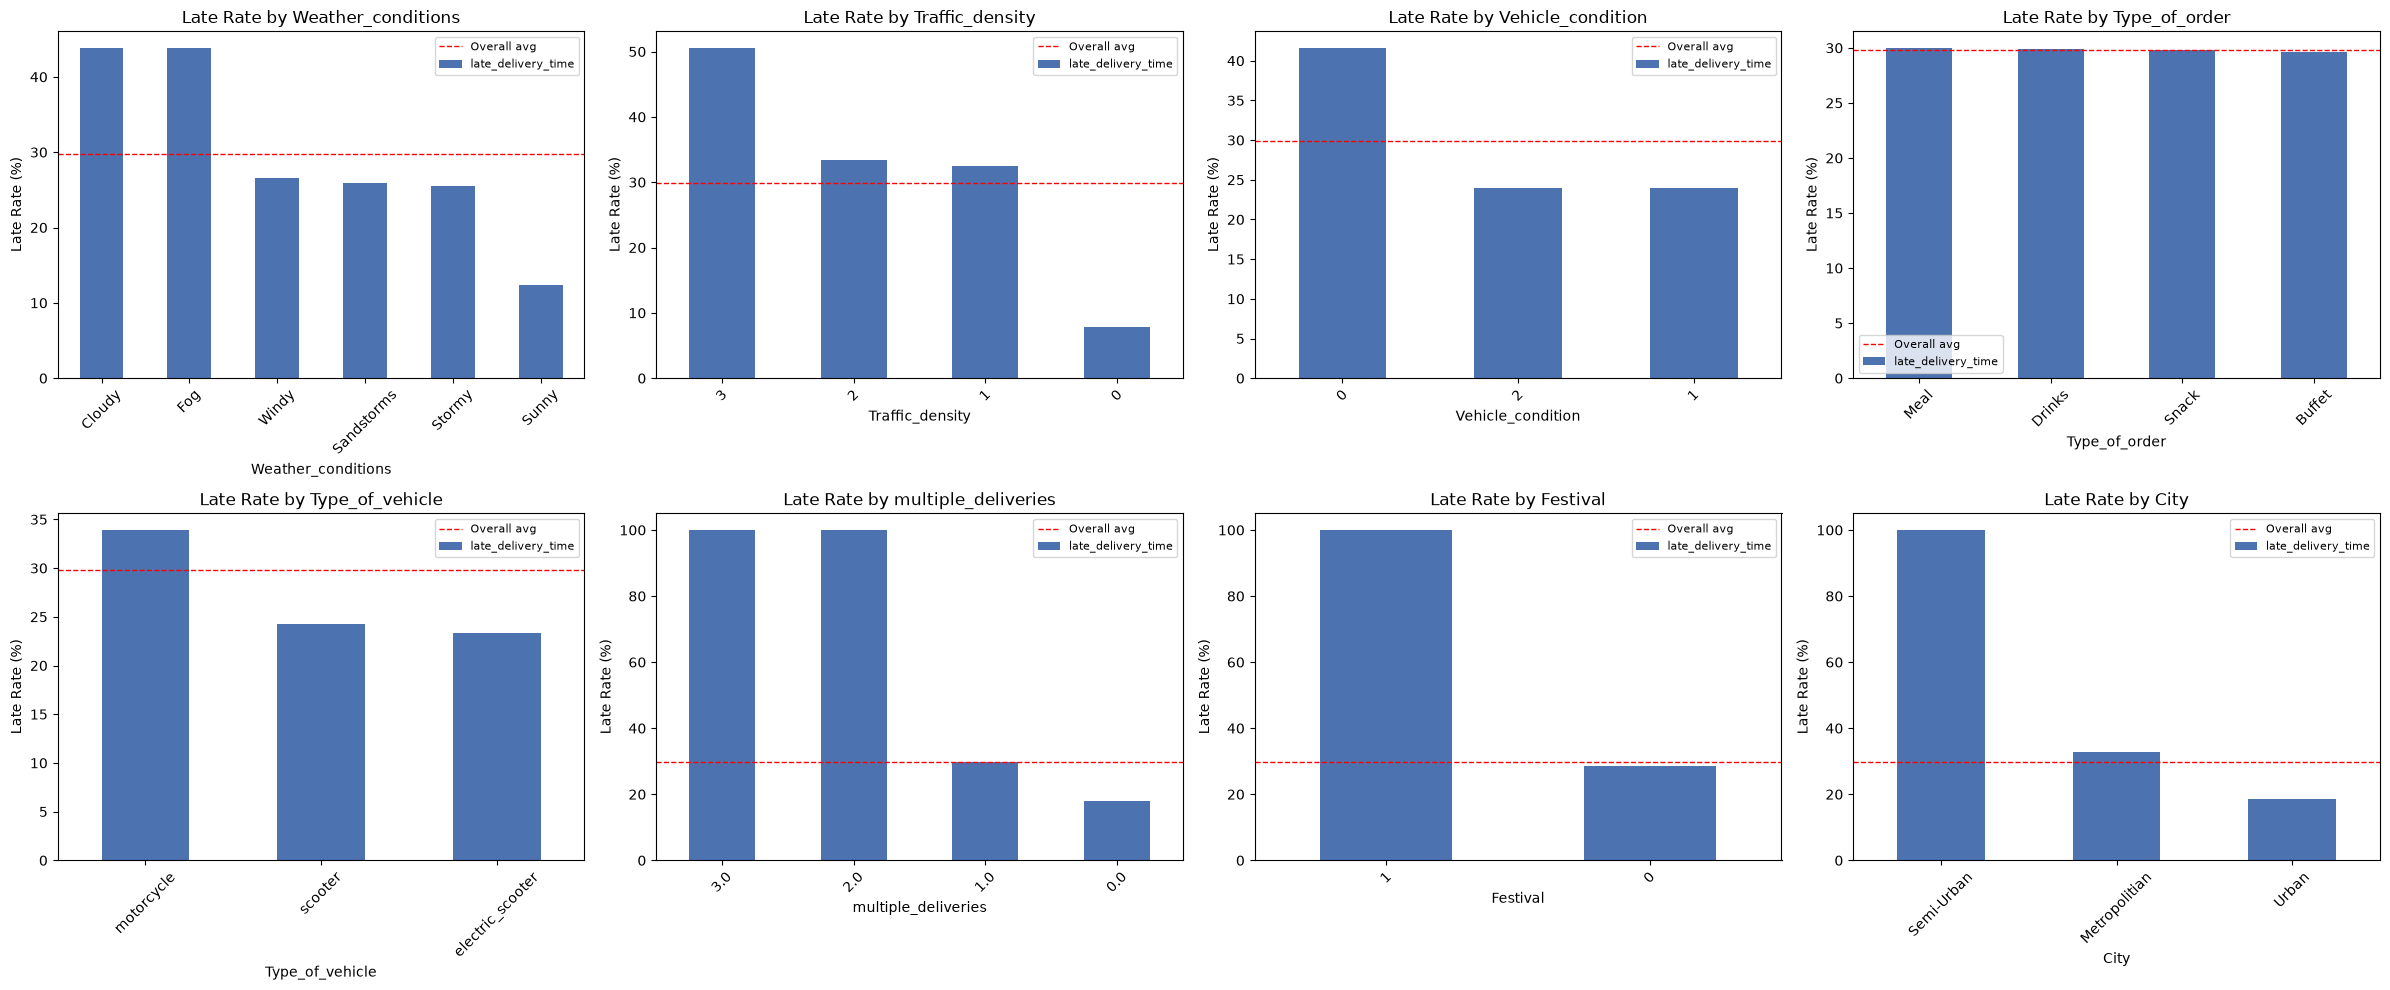

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(24, 10))
axes = axes.flatten()

for ax, feature in zip(axes, cat_features):
    rate = df.groupby(feature)['late_delivery_time'].mean().sort_values(ascending=False) * 100
    rate.plot(kind='bar', ax=ax, color='#4C72B0')
    ax.set_title(f'Late Rate by {feature}')
    ax.set_ylabel('Late Rate (%)')
    ax.axhline(df['late_delivery_time'].mean()*100, color='red', linestyle='--', linewidth=1, label='Overall avg')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()